# Assignment 1- Xiaole Zuo

## Data preprocess

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# New base directory after extraction
base_dir = './ml-1m'

# Paths to the specific files
movies_path = os.path.join(base_dir, 'movies.dat')
ratings_path = os.path.join(base_dir, 'ratings.dat')

# Load data, specifying the encoding as Latin-1
movies = pd.read_csv(movies_path, delimiter='::', engine='python', names=['MovieID', 'Title', 'Genres'], header=None, encoding='latin-1')
ratings = pd.read_csv(ratings_path, delimiter='::', engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'], header=None, encoding='latin-1')

# Prepare genres
movies['Genres'] = movies['Genres'].str.split('|')
movies = movies.explode('Genres')

# Merge ratings with movies
merged_data = pd.merge(ratings, movies, on='MovieID')

# Display the size of first row of the merged data
print(merged_data.shape)
print(merged_data.head())

(2101815, 6)
   UserID  MovieID  Rating  Timestamp                                   Title  \
0       1     1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)   
1       2     1193       5  978298413  One Flew Over the Cuckoo's Nest (1975)   
2      12     1193       4  978220179  One Flew Over the Cuckoo's Nest (1975)   
3      15     1193       4  978199279  One Flew Over the Cuckoo's Nest (1975)   
4      17     1193       5  978158471  One Flew Over the Cuckoo's Nest (1975)   

  Genres  
0  Drama  
1  Drama  
2  Drama  
3  Drama  
4  Drama  


## design the ETC algorithm

In [2]:
# Explore-then-Commit Algorithm
class ETCBandit:
    def __init__(self, k, exploration_phase):
        self.k = k  # number of arms
        self.exploration_phase = exploration_phase  # number of times to explore each arm
        self.counts = np.zeros(k)  # counts of selections for each arm
        self.sums = np.zeros(k)  # sum of rewards for each arm

    def pull(self, arm, reward):
        """Update the counts and sums after pulling an arm """
        self.counts[arm] += 1
        self.sums[arm] += reward

    def get_best_arm(self):
        """ Return the arm with the highest average reward after exploration """
        averages = self.sums / self.counts
        return np.argmax(averages), averages  # return the biggest arm(index) of averages


def simulate_etc(data, genres, horizon, experiment_phase_frequency):
    exploration_phase = int(horizon * experiment_phase_frequency)
    k = len(genres)
    m = exploration_phase // k
    bandit =ETCBandit(k, exploration_phase)

    # Initialize cumulative regret list
    cumulative_regret = np.zeros(horizon)
    # Initialize an array to store cumulative rewards at each step
    total_actual_rewards = np.zeros(horizon)

    # Exploration phase
    for arm in range(k):
        arm_genre = genres[arm]
        filtered_data = data[data['Genres'] == arm_genre]
        for t in range(m):
            reward = np.random.choice(filtered_data['Rating'])
            bandit.pull(arm, reward)
            if t < horizon:
                total_actual_rewards[t] = reward if t == 0 else total_actual_rewards[t-1] + reward

    # print(bandit.counts)
    # print(bandit.sums)

    # Calculate the best arm
    best_arm, average_reward = bandit.get_best_arm()
    best_genre = genres[best_arm]
    # print(reward[reward['Genres']==best_genre] * horizon)

    # Calculate the maximum possible reward with the optimal strategy
    best_rating = bandit.sums[best_arm] / bandit.counts[best_arm]
    optimal_rewards = best_rating * np.arange(1, horizon + 1)  # Cumulative optimal rewards over time
    # print(optimal_rewards)

    # Commit phase
    filtered_data = data[data['Genres'] == genres[best_arm]]
    for t in range(m * k, horizon):
        reward = np.random.choice(filtered_data['Rating'])
        total_actual_rewards[t] = total_actual_rewards[t - 1] + reward
    # print(total_actual_rewards)

    # Calculate cumulative regret at each time step
    cumulative_regret = optimal_rewards - total_actual_rewards

    return cumulative_regret

'''
    # Calculate the maximum possible reward with optimal strategy
    best_rating = bandit.sums[best_arm] / bandit.counts[best_arm]
    optimal_rewards = best_rating * horizon
    # print(optimal_rewards)

    # Commit phase
    actual_rewards = m * sum(average_reward) + (horizon - m * k) * best_rating
    # print(average_reward)

    # Calculate the cumulative regret
    regret = optimal_rewards - actual_rewards

    return regret
'''



genres = merged_data['Genres'].unique()
horizon = 100000
regret = simulate_etc(merged_data, genres, horizon, 0.1)
print("cumulative regret:", regret)

cumulative regret: [ 1.04504505e-01  2.09009009e-01 -6.86486486e-01 ...  4.38412414e+04
  4.38423459e+04  4.38414505e+04]


## Solve the problem 1

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


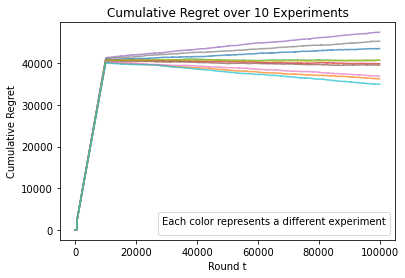

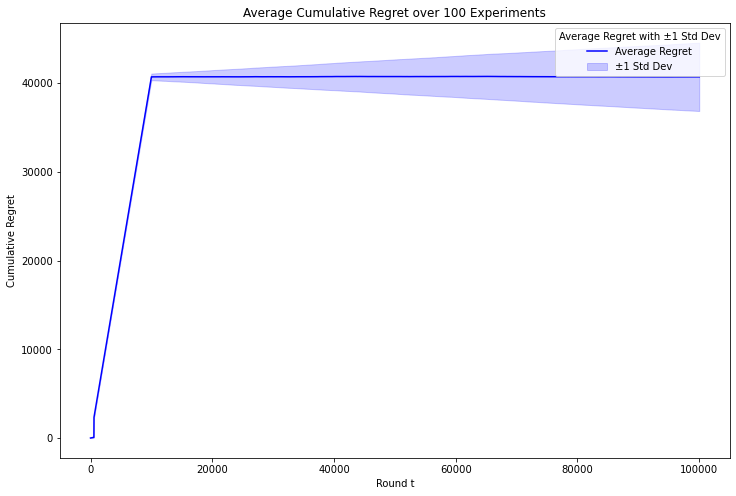

In [3]:
def run_10_experiments(data, genres, horizon):
    regrets = []
    for _ in range(10):
        cumulative_regret = simulate_etc(data, genres, horizon, 0.1)
        plt.plot(cumulative_regret, alpha=0.7)

    plt.title('Cumulative Regret over 10 Experiments')
    plt.xlabel('Round t')
    plt.ylabel('Cumulative Regret')
    plt.legend(title="Each color represents a different experiment")  # Add legend to show labels
    plt.show()

def run_100_experiments(data, genres, horizon):
    all_regrets = []

    # Run 100 experiments
    for _ in range(100):
        cumulative_regret = simulate_etc(data, genres, horizon, 0.1)
        all_regrets.append(cumulative_regret)

    # Convert list of regrets to a numpy array for easier manipulation
    all_regrets = np.array(all_regrets)

    # Calculate mean and standard deviation
    mean_regret = np.mean(all_regrets, axis=0)  # mean of regrets in each round t
    std_regret = np.std(all_regrets, axis=0)

    # Plot the average regret with error bars
    plt.figure(figsize=(12, 8))
    plt.plot(mean_regret, label='Average Regret', color='blue')
    plt.fill_between(np.arange(1, horizon + 1),
                     mean_regret - std_regret,
                     mean_regret + std_regret,
                     color='blue',
                     alpha=0.2,
                     label='±1 Std Dev')

    plt.title('Average Cumulative Regret over 100 Experiments')
    plt.xlabel('Round t')
    plt.ylabel('Cumulative Regret')
    plt.legend(title="Average Regret with ±1 Std Dev")
    plt.show()


# For the porblem 1
run_10_experiments(merged_data, genres, horizon)
run_100_experiments(merged_data, genres, horizon)


### Comments:
From the picture about ('Cumulative Regret over 10 Experiments'), we can see that:
1. cummulative regrets with different experiments rose dramatically during the exploration phase, then became slower than before even became stable during the committing period;
2. during the exploration phase, cummulative regrets with different experiments were similar, while becoming different during the committing period.

In my opinion, in the exploration phase, each arm is selected a fixed number of times, and each time a reward is randomly drawn from the corresponding reward distribution. Since all experiments follow the exact same selection pattern during the exploration phase, meaning each arm is explored the same number of times across experiments and they all follow the same reward distribution, there is no significant difference in cumulative regret across the different experiments during this phase. However, in the committing phase, the maximum regret is determined based on the previous phase, and then rewards are randomly selected from the best arm. Since the rewards randomly selected in each experiment are different, the cumulative regrets will vary slightly between experiments in this phase.
And that is why only regrets in committing phase had confidence interval from the picture of ('Average Cumulative Regret over 100 Experiments').

## Solve the Problem 2

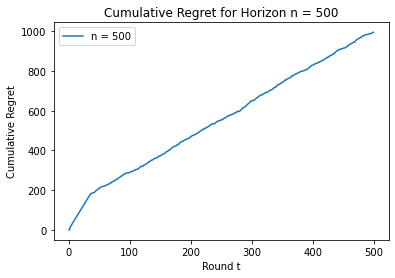

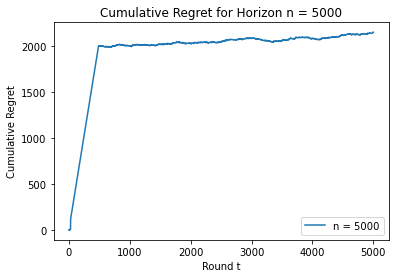

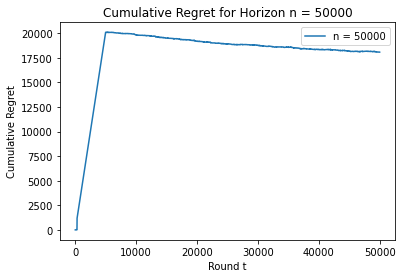

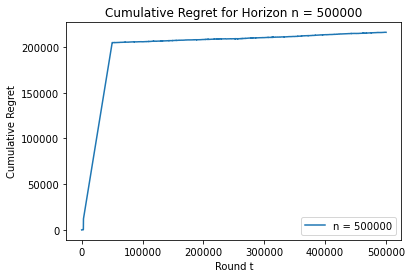

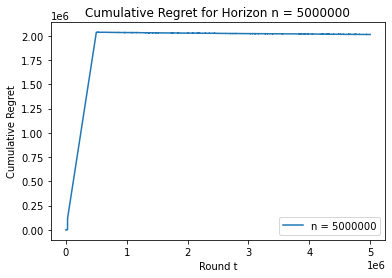

In [8]:
# For the problem 2
def run_experiments_for_different_horizon(data, genres):
    horizon_values = [500, 5000, 50000, 500000, 5000000]

    for horizon in horizon_values:
        cumulative_regret = simulate_etc(data, genres, horizon, 0.1)
        plt.plot(cumulative_regret, label=f'n = {horizon}')

        plt.title(f'Cumulative Regret for Horizon n = {horizon}')
        plt.xlabel('Round t')
        plt.ylabel('Cumulative Regret')
        plt.legend()
        plt.show()


# Call the function to run experiments for different horizon values
run_experiments_for_different_horizon(merged_data, merged_data['Genres'].unique())


### Comments:
Observing these 5 pictures with different horizons, we can see that in the same $horizon\times 0.1$ experiment phase, the ditribution of cummulative regret got more logarithmic behavior, as the horizons rose at the same time.

The reason for this phenomenon is that as the horizon increases, the exploration phase also becomes longer, meaning each arm is selected more frequently. With more data being gathered during exploration, the decision regarding the best arm becomes more accurate, and the average reward corresponding to the optimal arm becomes more stable. Consequently, in the committing phase, the rewards randomly selected from the best arm are less likely to deviate significantly from the average reward, leading to a smoother or even stable trend in the cumulative regret over time.

## Solve the problem 3

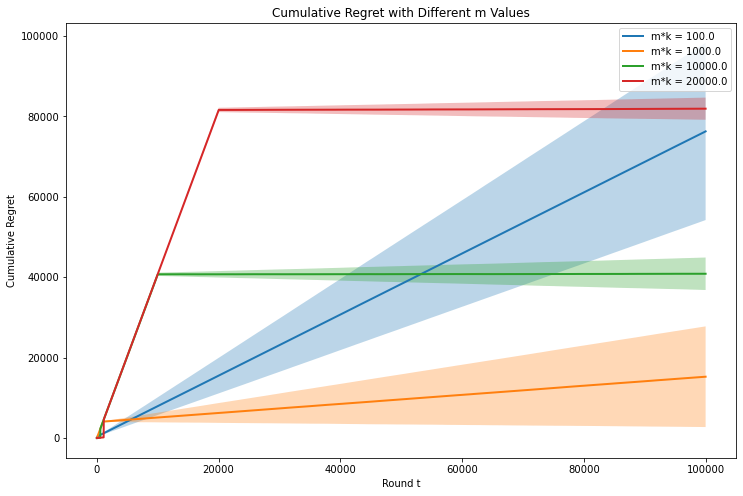

In [9]:
# For the problem 3
def run_experiment_with_frequency(data, genres, horizon, frequency):
    cumulative_regrets = []
    for _ in range(100):  # Run 100 experiments
        cumulative_regret = simulate_etc(data, genres, horizon, frequency)
        cumulative_regrets.append(cumulative_regret)

    return np.array(cumulative_regrets)


def plot_results(experiment_phase_frequency, cumulative_regrets_list):
    plt.figure(figsize=(12, 8))

    for frequency, cumulative_regrets in zip(experiment_phase_frequency, cumulative_regrets_list):
        mean_regret = np.mean(cumulative_regrets, axis=0)
        std_dev = np.std(cumulative_regrets, axis=0)
        plt.plot(mean_regret, label=f'm*k = {horizon*frequency}', linewidth=2)
        plt.fill_between(range(1, len(mean_regret) + 1),
                         mean_regret - std_dev,
                         mean_regret + std_dev, alpha=0.3)

    plt.title('Cumulative Regret with Different m Values')
    plt.xlabel('Round t')
    plt.ylabel('Cumulative Regret')
    plt.legend()
    plt.show()

"""To see the effect of m, I don't like to change simulate_etc,
so I just change the experiment phase by changing the frequency """
"""m = [100, 1000, 10000, 20000] is equivalent in 
experiment_phase_frequency = [0.001, 0.01, 0.1, 0.2]"""
experiment_phase_frequency = [0.001, 0.01, 0.1, 0.2]

# Run the experiments for each m value
cumulative_regrets_list = []
for frequency in experiment_phase_frequency:
    cumulative_regrets = run_experiment_with_frequency(merged_data, genres, 100000, frequency)
    cumulative_regrets_list.append(cumulative_regrets)

# Plot the results
plot_results(experiment_phase_frequency, cumulative_regrets_list)

### Commit:
Just what I said in problem 2, even though ETC was changed by the number of horizons, the number of chosen datas in different arms (in this problem called "$\mathcal{m}$") was the most influenced. And this problem changed $\mathcal{m}$ directly,so <u>as $\mathcal{m}$ was becoming large, the distribution of cummulative regret was more likely to obey the logarithmic behavior.</u>

What's more, due to the <u> increased amount of data in the exploration phase, the calculated cumulative regret also grows accordingly</u>. This explains why the cumulative regret upper bound is higher for experiments with larger values of $\mathcal{m}$. Moreover, since the selection strategy remains consistent, the rate of cumulative regret growth during the exploration phase is almost identical across different experiments. In other words, <u>the growth rate of cumulative regret is nearly the same for all these experiments.</u>